### Libraries.

In [1]:
from itertools import chain

from anndata import AnnData
from matplotlib import rcParams
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import seaborn as sns
from scipy.stats import norm
from scipy import special
import torch
from tqdm import tqdm

from sc_exp_design.data import DataManager, SequentialDataLoader
from sc_exp_design.sym import GaussianMixtureModel

# defining figure size
FIGSIZE = (3, 3)
rcParams["figure.figsize"] = FIGSIZE


### Reading data.

In [2]:
PATH = "../../theis/HID01_fcs_concatenated.h5ad"
adata = sc.read_h5ad(PATH)
adata


AnnData object with n_obs × n_vars = 93278696 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'

### Subsampling the data.

In [3]:
# optionally subsample the data
KEEP_COPY = True
SUBSAMPLE = True
SUBSAMPLING_DONE = False
SUBSAMPLE_SIZE = 5e-3

if SUBSAMPLE and not SUBSAMPLING_DONE:
    if KEEP_COPY:
        adata_original = adata.copy()
        sc.pp.subsample(adata, SUBSAMPLE_SIZE)
    SUBSAMPLING_DONE = True
adata


AnnData object with n_obs × n_vars = 466393 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'

### Constructing Annotated Data for Scatter Features. 

In [4]:
SCATTER_COLUMNS = ['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width']
scatter_df = adata.obs[SCATTER_COLUMNS]
X_scatter = scatter_df.values
adata_scatter = AnnData(X=X_scatter)
adata_scatter


AnnData object with n_obs × n_vars = 466393 × 6

### Plotting FSC-A against SSC-A.

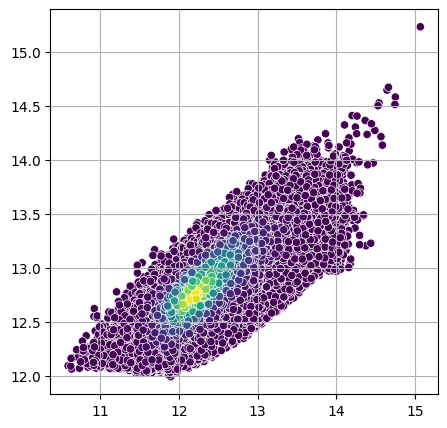

In [8]:
import scipy

transform_fn = lambda x: np.log(x)
# transform_fn = lambda x: x
compute_kernel = True
X = transform_fn(scatter_df[['SSC - Area']].values[:,0])
Y = transform_fn(scatter_df[['FSC - Area']].values[:,0])
values = np.vstack([X, Y])
kernel = None

if compute_kernel:
    kernel = scipy.stats.gaussian_kde(values)(values)
plt.figure(figsize=(5, 5))
sns.scatterplot(x=X,y=Y,c=kernel,)
plt.grid(True)


In [ ]:

def NxNPlot(
    data_id: str,
    data: np.ndarray,
    int2antibody: dict[str, int],
    compute_kernel: bool=True,
    dump_path: str=None,
):
    fig, axes = plt.subplots(data.shape[1], data.shape[1], figsize=(45, 45))
    fig.suptitle(data_id)
    for ridx in range(axes.shape[0]):
        for cidx in range(axes.shape[0]):
            print(ridx, cidx)
            if cidx <= ridx:
                continue
            rantibody = int2antibody[ridx]
            cantibody = int2antibody[cidx]
            X, Y = data[:, ridx], data[:, cidx]
            values = np.vstack([X, Y])
            kernel = None
            if compute_kernel:
                PDF = fastkde.pdf(X, Y, var_names = [rantibody, cantibody])
                PDF.plot(ax=axes[ridx, cidx])
            sns.scatterplot(x=X,y=Y,ax=axes[ridx, cidx])
            axes[ridx, cidx].set_xlabel(rantibody)
            axes[ridx, cidx].set_ylabel(cantibody)
            axes[ridx, cidx].grid(True)
    # fig.savefig(os.path.join(dump_path, f"{data_id}_NxNPlot.png"))

# mapping to antibody
int2antibody = {
    idx: adata.var.iloc[idx][["antibody"]].values[0] for idx in range(adata.var.shape[0])
}
antibody2idx = {v:k for k, v in int2antibody.items()}

# raw channel features
key_raw = f"X_channel_raw"
X_channel_raw = adata.X
NxNPlot(
    key_raw,
    X_channel_raw,
    int2antibody,
    # COMPUTE_KERNEL,
    # DUMP_PATH,
)


0 0
0 1
0 2
0 3
0 4
0 5
0 6
0 7
0 8
0 9
0 10
0 11
0 12
0 13
0 14
0 15
0 16
0 17
0 18
0 19
0 20
1 0
1 1
1 2
1 3
1 4
1 5
1 6
1 7
1 8
1 9
1 10
1 11
1 12
1 13
1 14
1 15
1 16
1 17
1 18
1 19
1 20
2 0
2 1
2 2
2 3
2 4
2 5
2 6
2 7
2 8
2 9
2 10
2 11
2 12
2 13
2 14
2 15
2 16
2 17
2 18
2 19
2 20
3 0
3 1
3 2
3 3
3 4
3 5
3 6
3 7
3 8
3 9
3 10
3 11
3 12
3 13
3 14
3 15
3 16
3 17
3 18
3 19
3 20
4 0
4 1
4 2
4 3
4 4
4 5
4 6
4 7
4 8
4 9
4 10
4 11
4 12
4 13
4 14
4 15
4 16
4 17
4 18
4 19
4 20
5 0
5 1
5 2
5 3
5 4
5 5
5 6
5 7
5 8
5 9
5 10
5 11
5 12
5 13
5 14
5 15
5 16
5 17
5 18
5 19
5 20
6 0
6 1
6 2
6 3
6 4
6 5
6 6
6 7
6 8
6 9
6 10
6 11
6 12
6 13
6 14
6 15
6 16
6 17
6 18
6 19
6 20
7 0
7 1
7 2
7 3
7 4
7 5
7 6
7 7
7 8
7 9
7 10
7 11
7 12
7 13
7 14
7 15
7 16
7 17
7 18
7 19
7 20
8 0
8 1
8 2
8 3
8 4
8 5
8 6
8 7
8 8
8 9
8 10
8 11
8 12
8 13
8 14
8 15
8 16
8 17
8 18
8 19
8 20
9 0
9 1
9 2
9 3
9 4
9 5
9 6
9 7
9 8
9 9
9 10
9 11
9 12
9 13
9 14
9 15
9 16
9 17
9 18
9 19
9 20
10 0
10 1
10 2
10 3
10 4
10 5
10 6
10 7
10 8
10 9


### Applying tranformations to channel features.

In [ ]:
adata.obsm["X"] = adata.X
COFACTORS = [100, 250, 300, 500, 750, 1_000, 1_500, 2_500, 5_000, 10_000]
for cofactor in COFACTORS:
    key_arcsin = f"X_arcsinh_cof{cofactor}"
    key_logabs = f"X_logabs_cof{cofactor}"
    print(f"Applying transformation for {cofactor=}")
    adata.obsm[key_arcsin] = np.arcsinh(adata.X/cofactor)
    adata.obsm[key_logabs] = np.sign(adata.X)*np.log(np.abs(adata.X / cofactor))
adata


### Applying tranformations to scatter features.

In [ ]:
adata_scatter.obsm["X"] = adata_scatter.X
COFACTORS = [0.1, 1, 10, 100, 1_000, 10_000]
for cofactor in COFACTORS:
    key_log = f"X_log_cof{cofactor}"
    print(f"Applying transformation for {cofactor=}")
    adata_scatter.obsm[key_log] = np.log(adata_scatter.X / cofactor)
adata_scatter


### Computing summary statistics for Scatter Features.

In [ ]:
# defining function for computing summary statistics
def compute_summary_stats(data):
    output = {}
    stats ={
        "min": np.min, "max": np.max, "mean": np.mean, "median": np.median, "std": np.std
    }
    for idx in range(2):
        output[idx] = {
            stat_id: stat_fn(data, axis=idx) for stat_id, stat_fn in stats.items()
        }
    output[None] = {
        stat_id: stat_fn(data) for stat_id, stat_fn in stats.items()
    }
    return output


scatter_summary_stats_dict = {}
scatter_summary_stats_dict["X_scatter"] = compute_summary_stats(X_scatter)

for key, val in adata_scatter.obsm.items():
    scatter_summary_stats_dict[key] = compute_summary_stats(val)

for key, val in scatter_summary_stats_dict.items():
    print(f"Summary stats for {key}:")
    for stats, stats_val in val[None].items():
        print(f"\t{stats}: {stats_val}")


### Histogram of Scatter Features.

In [ ]:
import fastkde

for key, value in adata_scatter.obsm.items():
    print(key)
    fig, axes = plt.subplots(1, value.shape[-1], figsize=(15, 5))
    fig.suptitle(key)
    for idx, col in enumerate(SCATTER_COLUMNS): 
        fastkde.pdf(value[:, idx], var_names=[col, ]).plot(ax=axes[idx])
        axes[idx].set_title(col)
        axes[idx].grid(True)
    fig.show()


### Histogram of Channel Features.

In [ ]:
for key, value in adata.obsm.items():
    print(key)
    fig, axes = plt.subplots(1, value.shape[-1], figsize=(30, 5))
    fig.suptitle(key)
    for idx, col in enumerate(adata.var_names): 
        fastkde.pdf(value[:, idx], var_names=[col, ]).plot(ax=axes[idx])
        axes[idx].set_title(col)
        axes[idx].grid(True)
    fig.show()


### Setting default cofactors per channel and inspecting resulting transformation.

In [ ]:
import numpy as np
import pandas as pd

# Define typical cofactor ranges by fluorochrome brightness
cofactor_by_fluor = {
    'PE': 200,
    'APC': 200,
    'AF350': 100,
    'AF700': 150,
    'APC-Cy7': 200,
    'BUV395': 100,
    'BUV563': 150,
    'BUV615': 150,
    'BUV661': 150,
    'BUV737': 150,
    'BV421': 150,
    'BV480': 150,
    'BV605': 150,
    'BV650': 150,
    'BV711': 150,
    'BV785': 150,
    'PE-Cy7': 200,
    'PE-Dazzle594': 200,
    'PE-Fire700': 200,
    'RB780': 150,
    'SparkBlue-550': 100,
    # fallback/default
    'unknown': 150
}

# Extract fluorochrome from channel name (e.g., 'PE' from 'PE-A')
def extract_fluor(channel):
    for fluor in cofactor_by_fluor:
        if fluor in channel:
            return f"{fluor}_A"
    return 'unknown'

# Build cofactor map
cofactor_map = {}
for idx, row in adata.var.iterrows():
    fluor = extract_fluor(row['channel'])
    cofactor = cofactor_by_fluor.get(fluor, 150)
    cofactor_map[idx] = cofactor

# Apply arcsinh transformation
X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X.copy()
for i, marker in enumerate(adata.var_names):
    cofactor = cofactor_map.get(marker, 150)
    X[:, i] = np.arcsinh(X[:, i] / cofactor)

# Save transformed data back
key = "X_default_cofs"
adata.obsm[key] = X
print("✅ Arcsinh transformation applied to AnnData.X with fluorochrome-based cofactors.")

fig, axes = plt.subplots(1, value.shape[-1], figsize=(30, 5))
fig.suptitle(key)
for idx, col in enumerate(adata.var_names):  
    sns.kdeplot(value[:, idx], ax=axes[idx]) 
    axes[idx].set_title(col)
    axes[idx].grid(True)
fig.show()


### Computing UMAP and PCA for each tranformations.

In [ ]:
obsm = adata.obsm.copy()
# iterating over the representations
for data_id, data in obsm.items():
    print(data_id)
    # copying to adata layers
    adata.layers[data_id] = data

    # handling keys
    pca_key = f"{data_id}_pca"
    neighbors_key = f"{data_id}_neighbors"
    umap_key = f"{data_id}_umap"

    # computing pca, neighbors and umap
    sc.pp.pca(adata, layer=data_id, key_added=pca_key)
    sc.pp.neighbors(adata, use_rep=f"{data_id}_pca", key_added=neighbors_key)
    sc.tl.umap(adata, neighbors_key=f"{data_id}_neighbors", key_added=umap_key)


### Visualizing the dimensionality reduced data.

In [ ]:
EXPERIMENTAL_COLUMNS = [
    'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]',
    'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]',
    'ldl_[ng/ml]', 'il3_[ng/ml]', 'o2_[%]', "experiment_id", "replicate", "well_id", 
    "plate", "date", "days_of_culture", "source_cell_phenotype"]

# iterating over the representations
for data_id, data in adata.obsm.items():
    # handling keys
    pca_key = f"{data_id}_pca"
    neighbors_key = f"{data_id}_neighbors"
    umap_key = f"{data_id}_umap"
    print(data_id)
    sc.pl.embedding(adata, color=EXPERIMENTAL_COLUMNS, basis=data_id,)
